In [2]:
# Import Library
import tensorflow as tf
import numpy as np
import keras
from sklearn.model_selection import train_test_split
import os
import matplotlib.pyplot as plt

In [3]:
# atur dimensi dan ambil datapath
# width = 136, height = 102
img_rows, img_cols = 102, 136
data_path = '/kaggle/input/datasets/hasibalmuzdadid/shoe-vs-sandal-vs-boot-dataset-15k-images/Shoe vs Sandal vs Boot Dataset/'
x, y = [], [] # list kosong buat image dan labelnya
counter = 0
classes = os.listdir(data_path) # ambil nama folder di dataset

print(classes)

['Shoe', 'Sandal', 'Boot']


In [4]:
# ambil image
# loop pertama buat ambil class
for class_path in os.listdir(data_path):
    # loop kedua buat ambil image di tiap class
    for img_path in os.listdir(data_path + class_path):
        path = f"{data_path}{class_path}/{img_path}"
        label = counter
        # nampung imagenya
        image = tf.keras.preprocessing.image.load_img(path, target_size=(img_rows, img_cols))
        image = tf.keras.preprocessing.image.img_to_array(image)
        x.append(image)
        y.append(label)
    counter += 1
    

x = np.array(x) 
y = np.array(y) 

# value x kan masih dalam bentuk RGB (0 - 255) kita ubah menjadi 0 - 1
x = x.astype('float32') / 255.0

# split data menjadi train, test dan validation
# Format 80:10:10
X_train, X_temp, y_train, y_temp = train_test_split(x, y, test_size=0.2, random_state=420)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=420)

# mengubah y menjadi one hot encoding
# hal ini dilakukan karena kita nanti akan pakai loss untuk categorical
y_train = keras.utils.to_categorical(y_train, num_classes=3)
y_val = keras.utils.to_categorical(y_val, num_classes=3)
y_test = keras.utils.to_categorical(y_test, num_classes=3)

print(X_train.shape)
# x_train = 12000 image
# Height = 102
# Width = 136
# channel = 3 (RGB: 3 atau GRAYSCALE: 1)

(12000, 102, 136, 3)


In [5]:
# preprocessing
model = keras.Sequential()

# filter = 6, 
# kernel_size = (5, 5) dengan default no padding jadi ukuran berkurang sesuai kernel sizenya [32 -> 28]
# activation relu efisien dan nonlinear jadi bisa ambil data kompleks
model.add(keras.layers.Conv2D(6, (5, 5), activation='relu', input_shape=(img_rows, img_cols, 3))) 
# strides itu untuk pembagian ukuran dari 28x28 jadi 14x14 (28 / 2 = 14)
model.add(keras.layers.AveragePooling2D(pool_size=(2, 2), strides=2))
model.add(keras.layers.Conv2D(16, (5, 5), activation='relu'))
model.add(keras.layers.AveragePooling2D(pool_size=(2, 2), strides=2))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(120, activation='relu'))
model.add(keras.layers.Dense(84, activation='relu'))
model.add(keras.layers.Dense(3, activation='softmax')) # sesuai dengan berapa banyak kelas kita
# softmax untuk dalam probability contoh: a, b, c = 0.85, 0.1, 0.05 maka diambil A = 0.85

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1790514547.526868      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790514547.529684      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 132, 6)     │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 49, 66, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 62, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 22, 31, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10912)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │     1,309,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           255 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,322,851 (5.05 MB)

 Trainable params: 1,322,851 (5.05 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# compile model
# sama kayak sebelumnya pakai adam lalu disini loss pakai categorical karena tidak hanya biner 
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# tadi train data kita 12000 pastikan batch_size bisa membagi 12000
history = model.fit(X_train, y_train, batch_size=120, validation_data=(X_val, y_val), epochs=10)

Epoch 1/10


2026-09-27 13:09:16.672460: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-27 13:09:16.813223: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 10/100 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4481 - loss: 1.0519

I0000 00:00:1790514559.481282     133 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.8021 - loss: 0.4887 - val_accuracy: 0.9020 - val_loss: 0.2737
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9143 - loss: 0.2297 - val_accuracy: 0.9220 - val_loss: 0.2123
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9412 - loss: 0.1653 - val_accuracy: 0.9293 - val_loss: 0.1826
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9529 - loss: 0.1282 - val_accuracy: 0.9453 - val_loss: 0.1451
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9611 - loss: 0.1055 - val_accuracy: 0.9393 - val_loss: 0.1597
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9645 - loss: 0.0972 - val_accuracy: 0.9560 - val_loss: 0.1369
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9738 - loss: 0.0726 - val_accuracy: 0.9533 - val_loss: 0.1327
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9819 - loss: 0.0489 - val_accuracy: 0.96

In [7]:
# evaluate
score = model.evaluate(X_test, y_test)
print(f"Test loss: {score[0]}")
print(f"Test Accuracy: {score[1]}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9733 - loss: 0.0730
Test loss: 0.07302048057317734
Test Accuracy: 0.9733333587646484


47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


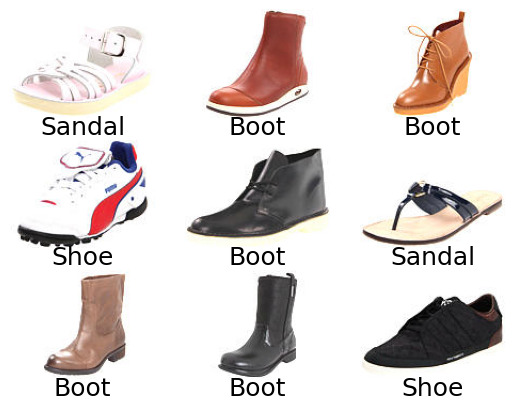

In [8]:
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis = 1)
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(X_test[i], cmap='gray') 
    plt.axis('off') # matiin axis supaya lebih rapi
    plt.text(0.5, -0.15, classes[predicted_labels[i]], fontsize = 18, ha='center', transform=plt.gca().transAxes)

# classes[predicted_labels[i]] = untuk mengubah angka menjadi nama kelasnya (contoh 1 menjadi "Boot")
# 0.5, -0.15: Koordinat posisi teks agar sedikit di bawah gambar dan agak tengah
# ha='center': Mengatur horizontal alignment text menjadi rata tengah.
# transform=plt.gca().transAxes: sistem koordinat relatif

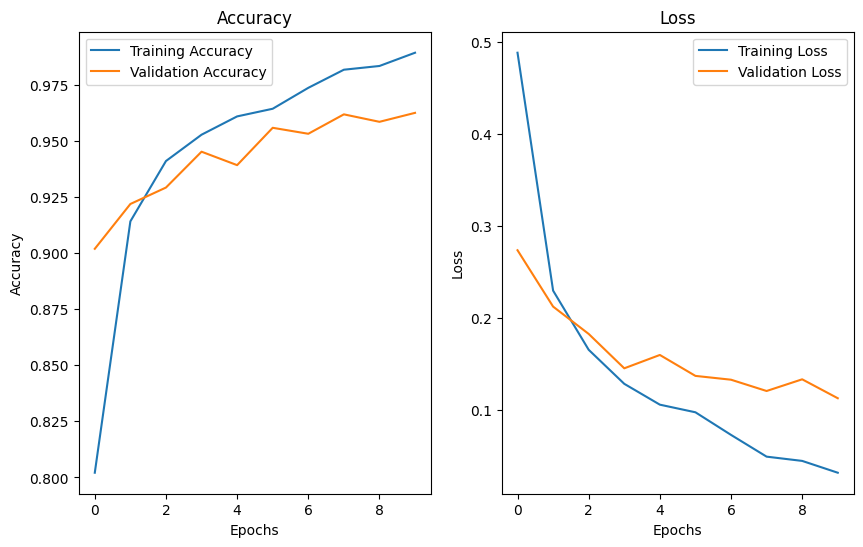

In [9]:
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label = "Training Accuracy")
plt.plot(history.history['val_accuracy'], label = "Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label = "Training Loss")
plt.plot(history.history['val_loss'], label = "Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title('Loss')
plt.legend()

plt.show()